# Long term shifts in North Atlantic seabird diet composition
### An unsupervised and supervised machine learning demonstration on 84 years of seabird monitoring data

**Author:** Erzsebet (Eli) Frey, ecologist (MSc Ecology, University of Belgrade)

**Context:** built as a one day methods demonstration in support of a PhD application
(Data Science / Bioinformatics for Marine and Arctic Biodiversity, AWI / MarDATA),
to show hands on use of supervised and unsupervised machine learning on real,
long term biodiversity monitoring data, plus the data harmonization skills the
position asks for. This is a portfolio style proof of concept, not a
peer reviewed analysis, see the Limitations section at the end.

**Data:** [seabirddietDB](https://github.com/annakrystalli/seabirddietDB)
(Krystalli, Olin, Grecian and Nager, 2019), a database of prey records collated
from published and grey literature for the ten most common seabird species
breeding in the British Isles, covering 1933 to 2017. MIT licensed. Each
record already carries a WoRMS AphiaID for both predator and prey, the same
kind of stable, cross database taxonomic identifier that GBIF and OBIS records
use, so this table could be joined to other AphiaID or GBIF backbone indexed
sources without renaming a single species.

**Why this dataset:** the posting asks for interpreting biodiversity patterns
from long term Arctic and marine monitoring data. This is genuine long term
(84 year) seabird monitoring data from Northeast Atlantic colonies (Isle of
May, Fair Isle, St Kilda and others), for species that also breed at Arctic
and Subarctic colonies AWI and partners monitor (common guillemot, black
legged kittiwake, Atlantic puffin, northern fulmar). It lets the same method
be demonstrated end to end today on open, reusable data, while being explicit
that scaling it to the Arctic sites named in the posting is future work, not
something claimed here.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from IPython.display import Image, display

from analysis import (
    load_raw, harmonize, build_composition_matrix, sandeel_trend_figure,
    run_unsupervised, run_species_classifier, run_era_classifier,
)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)


## 1. Load and harmonize

The raw table uses ad hoc column names (`pred_valid_name`, `freq_occ`, ...).
The harmonization step below renames these into a documented occurrence
style schema (`predatorScientificName`, `frequencyOfOccurrence`, ...),
following Darwin Core terms where a direct analogue exists, and keeps the
WoRMS AphiaIDs as the durable taxonomic key. This is the same kind of
"compile and harmonize datasets from diverse sources" step the posting
lists as a required skill, just performed here on one well documented
source so it is fully reproducible in a day.

In [2]:
df = load_raw()
occ = harmonize(df)
print(f"{occ.shape[0]} harmonized diet records, {occ['predatorScientificName'].nunique()} predator species, "
      f"{occ['preyScientificName'].nunique()} prey taxa, {occ['locality'].nunique()} colonies, "
      f"years {occ['year'].min()}-{occ['year'].max()}")
occ.head()


2011 harmonized diet records, 8 predator species, 123 prey taxa, 62 colonies, years 1933-2017


,recordID,year,decimalLatitude,decimalLongitude,locality,predatorScientificName,predatorAphiaID,predatorCommonName,breedingStatus,preyScientificName,preyAphiaID,frequencyOfOccurrence,sampleSize,referenceID
0,1,1973,52.17,-9.75,Co. Kerry,Fratercula arctica,137131,Atlantic puffin,breeding,Ammodytidae,125516,0.192,78.0,REF028
1,2,1973,52.17,-9.75,Co. Kerry,Fratercula arctica,137131,Atlantic puffin,breeding,Gaidropsarus,125743,0.000,78.0,REF028
2,3,1973,52.17,-9.75,Co. Kerry,Fratercula arctica,137131,Atlantic puffin,breeding,Melanogrammus aeglefinus,126437,0.000,78.0,REF028
3,4,1973,52.17,-9.75,Co. Kerry,Fratercula arctica,137131,Atlantic puffin,breeding,Merlangius merlangus,126438,0.000,78.0,REF028
4,5,1973,52.17,-9.75,Co. Kerry,Fratercula arctica,137131,Atlantic puffin,breeding,other,NaN,0.038,78.0,REF028


## 2. From records to a community composition matrix

Each row above is one prey taxon recorded for one predator species at one
colony in one year. Pivoting this into a **colony year x prey taxon**
matrix (frequency of occurrence as the value) gives the same kind of
community matrix ecologists build from transect or camera trap data, just
for diet composition instead of species presence. Rare prey taxa (outside
the 40 most recorded) are pooled into an "other" category, and sample units
with fewer than 3 prey taxa recorded are dropped as too sparse to
characterise a diet.

In [3]:
wide, meta = build_composition_matrix(occ)
print(f"{wide.shape[0]} colony year diet samples x {wide.shape[1]} prey groups")
meta["predatorCommonName"].value_counts()


321 colony year diet samples x 41 prey groups


predatorCommonName
Common guillemot          135
Black-legged kittiwake     83
Atlantic puffin            59
European shag              21
Northern fulmar             9
Northern gannet             7
Razorbill                   6
Manx Shearwater             1
Name: count, dtype: int64

## 3. Unsupervised: does diet composition alone reveal structure?

Composition data like this (bounded frequencies, many zeros) is not well
served by Euclidean distance, so clustering here uses **Bray Curtis
dissimilarity** with average linkage (UPGMA), the standard community
ecology approach, and the result is visualised with **non metric
multidimensional scaling (NMDS)** rather than PCA, again to match how this
kind of compositional data is normally ordinated. The number of clusters is
chosen by silhouette score, restricted to solutions where no cluster is a
one or two point outlier.

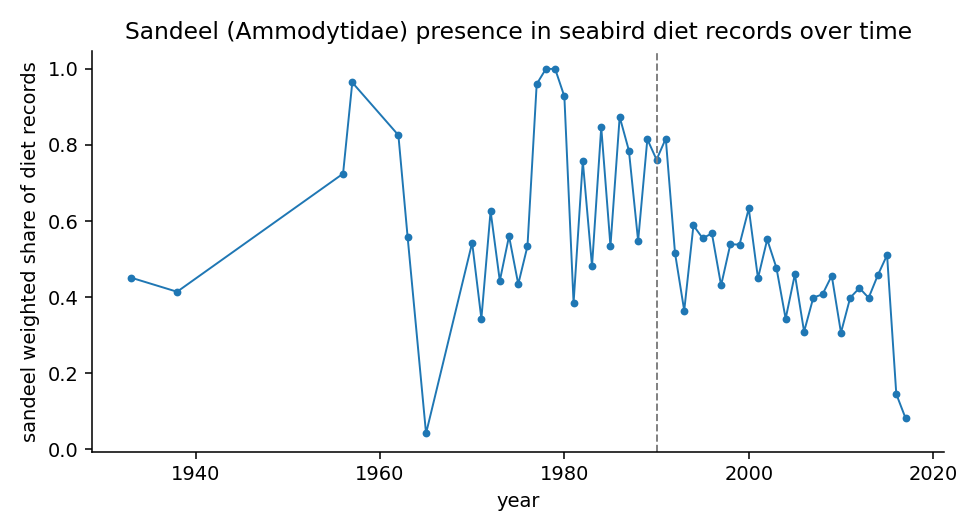

In [4]:
sandeel_trend_figure(occ)
display(Image(filename="figures/00_sandeel_trend.png"))


Chosen k = 4


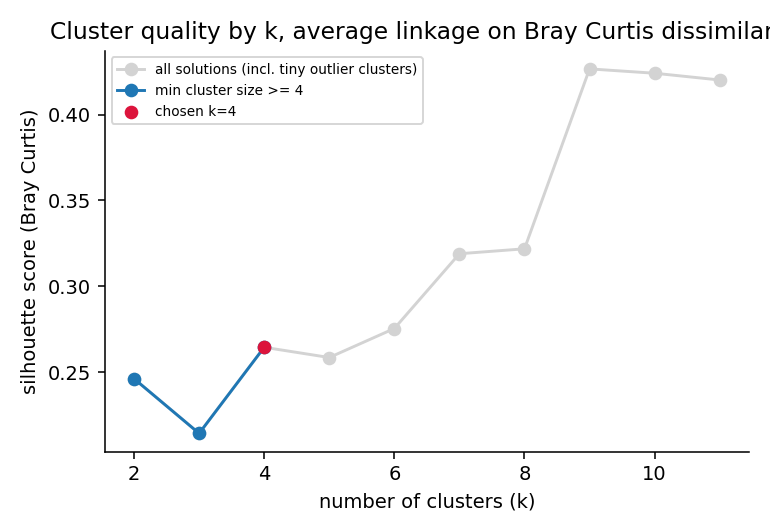

In [5]:
(meta, best_k, sil_scores, era_vs_cluster, ari_era,
 cluster_vs_species, ari_species) = run_unsupervised(wide, meta)

print(f"Chosen k = {best_k}")
display(Image(filename="figures/01_silhouette_by_k.png"))


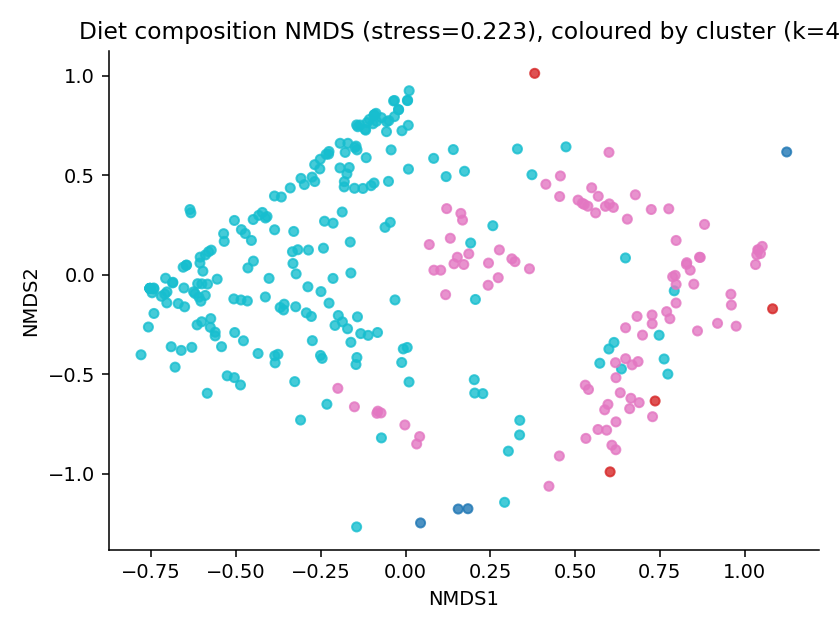

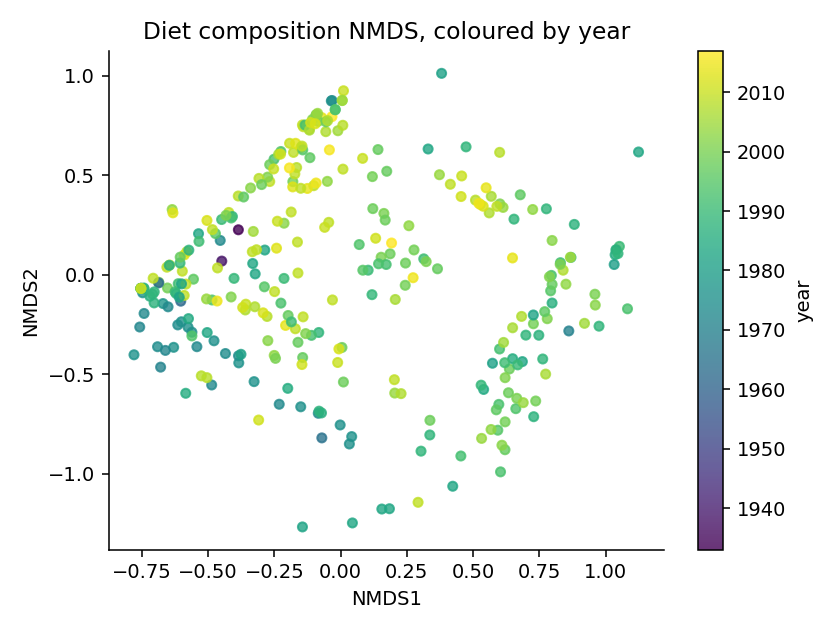

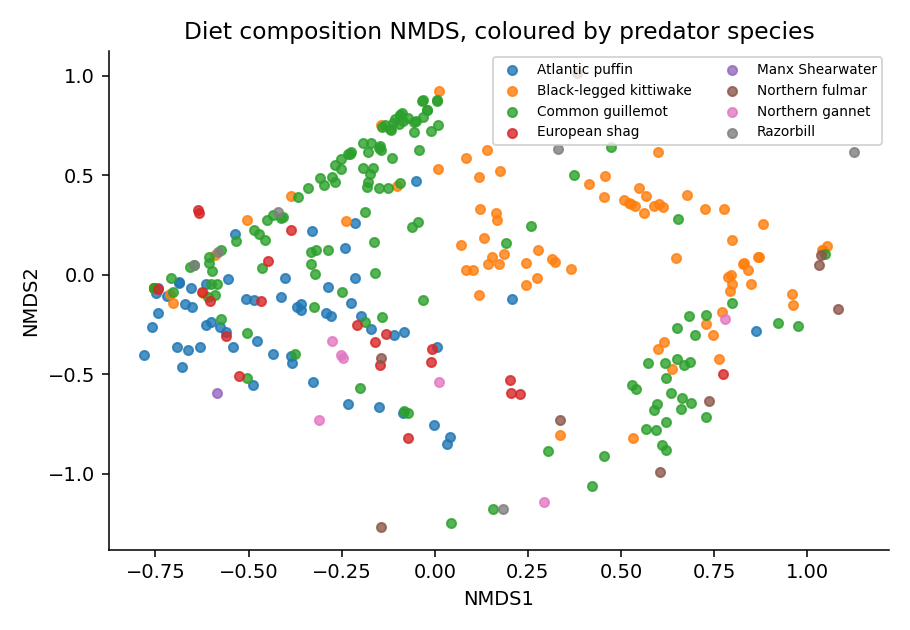

In [6]:
display(Image(filename="figures/02_pca_by_cluster.png"))
display(Image(filename="figures/03_pca_by_year.png"))
display(Image(filename="figures/04_pca_by_species.png"))


In [7]:
print("Cluster membership vs pre/post 1990 era:")
display(era_vs_cluster)
print(f"Adjusted Rand index, cluster vs era: {ari_era:.3f}")
print()
print("Cluster membership vs predator species:")
display(cluster_vs_species)
print(f"Adjusted Rand index, cluster vs species: {ari_species:.3f}")


Cluster membership vs pre/post 1990 era:


era,1990 or later,before 1990
cluster,,
1,0,4
2,3,1
3,69,28
4,149,67


Adjusted Rand index, cluster vs era: 0.006

Cluster membership vs predator species:


predatorCommonName,Atlantic puffin,Black-legged kittiwake,Common guillemot,European shag,Manx Shearwater,Northern fulmar,Northern gannet,Razorbill
cluster,,,,,,,,
1,0,0,2,0,0,0,0,2
2,0,0,0,0,0,4,0,0
3,6,55,33,0,0,2,1,0
4,53,28,100,21,1,3,6,4


Adjusted Rand index, cluster vs species: 0.085


**Reading the unsupervised result honestly:** clustering on diet
composition alone does not cleanly recover either the predator species or
a pre/post 1990 split (both adjusted Rand indices are close to zero). The
NMDS plot coloured by year also shows no obvious visual gradient. That is
a real result, not a failed one: it suggests the multi decade shift in
prey availability (see the sandeel trend above) moves diet composition
along a continuous, multivariate gradient rather than producing sharply
separated regimes, and it is exactly the kind of pattern a supervised
model, tested next, can still pick up even when unsupervised clustering
cannot draw a clean boundary.

## 4. Supervised: predicting predator species from diet

If different seabird species partition their prey differently (dietary
niche separation), a classifier should be able to recover species identity
from the composition vector alone. A random forest is used here for its
robustness to the many, mostly zero features in a composition matrix like
this, and because its feature importances double as an interpretable
summary of which prey taxa matter, which a black box model would not
give as directly.

Held out accuracy: 0.853
5 fold cross validated accuracy: 0.873 +/- 0.025


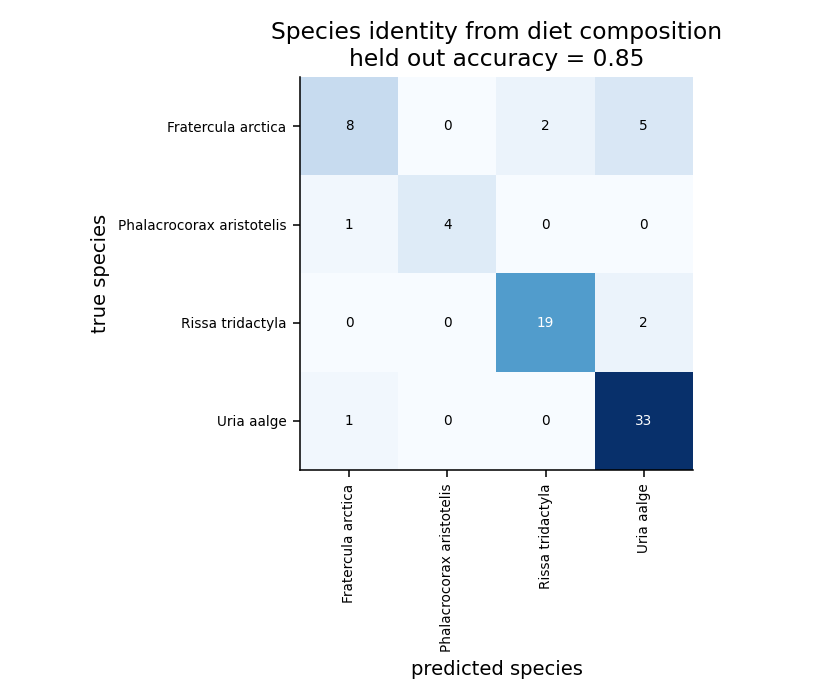

In [8]:
acc, cv_scores, fi_species = run_species_classifier(wide, meta)
print(f"Held out accuracy: {acc:.3f}")
print(f"5 fold cross validated accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
display(Image(filename="figures/05_species_confusion_matrix.png"))


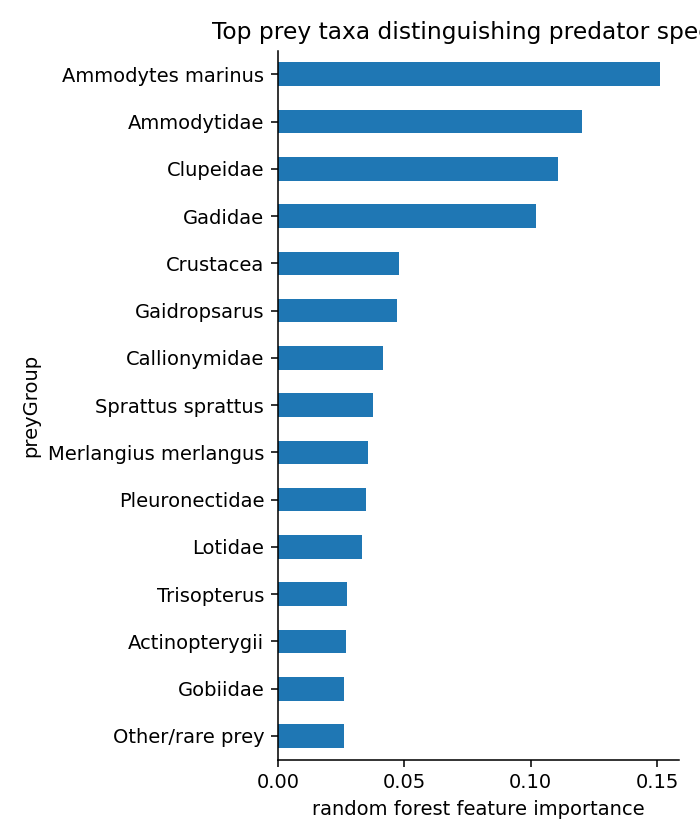

In [9]:
display(Image(filename="figures/06_species_feature_importance.png"))


Sandeels (*Ammodytes marinus* and the wider Ammodytidae family) are by
far the strongest signal for telling species apart, which matches what is
well documented in the seabird ecology literature for this system: species
like the Atlantic puffin rely on sandeels far more heavily than species
like the European shag, which take a broader range of demersal fish.

## 5. Supervised: predicting monitoring "era" from diet composition

This is the closer analogue to the kind of "supervised algorithms for
environmental predictions" the posting asks for: instead of predicting a
species label, the model is given only the diet composition of a sample and
asked to predict whether that sample comes from before or after 1990,
without ever being told the year or location. If it can do this reliably,
diet composition is acting as a biological proxy for a real environmental/
ecosystem state change, exactly the kind of pattern a long term Arctic
monitoring programme would want a model to detect automatically.

Held out accuracy: 0.864 (majority class baseline: 0.691)
Held out ROC AUC: 0.864
5 fold cross validated ROC AUC: 0.855 +/- 0.058


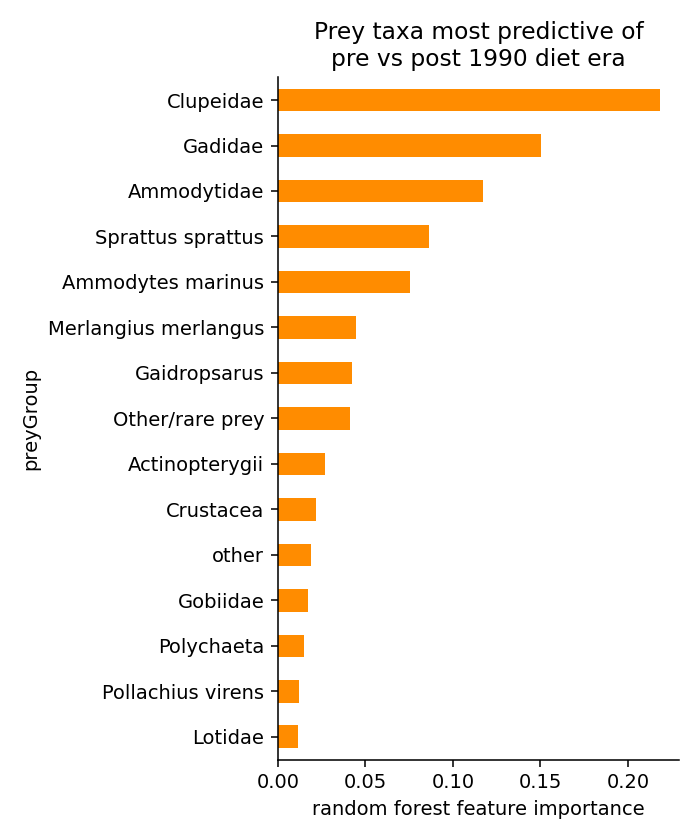

In [10]:
result = run_era_classifier(wide, meta, threshold_year=1990)
acc_e, auc_e, cv_e, fi_era, baseline = result
print(f"Held out accuracy: {acc_e:.3f} (majority class baseline: {baseline:.3f})")
print(f"Held out ROC AUC: {auc_e:.3f}")
print(f"5 fold cross validated ROC AUC: {cv_e.mean():.3f} +/- {cv_e.std():.3f}")
display(Image(filename="figures/07_era_feature_importance.png"))


The model clears the majority class baseline by a wide margin (about
17 percentage points of accuracy, ROC AUC around 0.86), using nothing but
prey composition. The prey taxa it leans on most, clupeids (herring and
sprat), gadids (cod family) and sandeels, are the same three fish groups at
the centre of the well documented North Sea fish community changes from
the late 20th century onward (the "gadoid outburst" and subsequent decline,
and the longer term sandeel decline linked to warming and fishing
pressure). The model recovering exactly those taxa as its top signal, with
no ecological information given to it beyond raw diet frequencies, is a
reasonable sanity check that it is learning something real rather than
noise.

## 6. Limitations, and how this would extend to the actual posting

This was built in a day from one open, MIT licensed dataset as a
demonstration of method, not a submission ready study. Specific
limitations worth being upfront about:

- The data covers British Isles/Northeast Atlantic colonies, not the
  Arctic monitoring sites named in the posting. The method (harmonize into
  a Darwin Core style table, build a composition matrix, Bray Curtis
  clustering plus NMDS, random forest with cross validation) transfers
  directly, but it has not been run on Arctic data here.
- Only 2011 of 2857 raw records had a usable frequency of occurrence value;
  rows without one were dropped rather than imputed.
- The "era" split at 1990 is a simplification chosen for the demonstration,
  not fitted to a specific documented regime shift year, and about a third
  of samples come from a single, very well sampled colony (Isle of May),
  so results may be more representative of that site than of the region
  as a whole.
- The NMDS ordination has a stress value in the range where it is a useful
  but not a highly precise two dimensional summary of the underlying
  Bray Curtis distances.
- No environmental covariates (sea surface temperature, sea ice extent,
  bathymetry) are used; the era classifier is picking up a biological
  proxy signal, not fitting an explicit environment to biology model.

For an actual Arctic long term monitoring programme, the natural next
steps would be: pulling real Arctic seabird or benthic occurrence data
from GBIF/OBIS/PANGAEA and harmonizing it against a dataset like this one
using the shared AphiaID/GBIF backbone keys, adding real environmental
covariates instead of a manual era split, and comparing the Bray Curtis
plus random forest baseline used here against the transformer based
sequence models mentioned as a preferred skill in the posting, for tasks
like eDNA based community composition where sequence data, not tabular
frequencies, is the primary input.
